# IMDB Movie Reviews - Text Classification

In [29]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"noga66","key":"55855fe42612d7de269b6b47f833af6b"}'}

In [30]:
!mv "kaggle (2).json" kaggle.json

In [31]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [32]:
!unzip imdb-dataset-of-50k-movie-reviews.zip

Archive:  imdb-dataset-of-50k-movie-reviews.zip
replace IMDB Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: IMDB Dataset.csv        


In [33]:
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


 Install & Import Libraries

In [34]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk gensim datasets -q

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

# NLTK Downloads
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


DATASET OVERVIEW
Total Samples : 50000
Columns       : ['review', 'sentiment']

Label Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


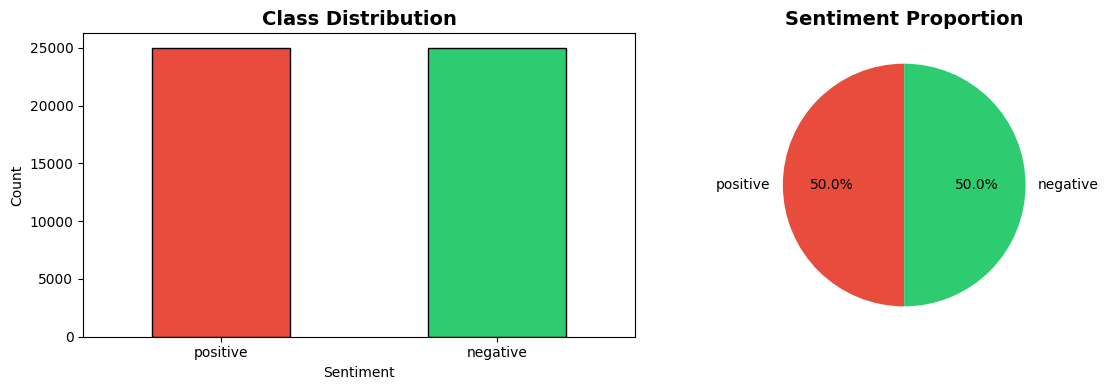

Plot saved.


In [36]:
# Dataset Overview
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Samples : {len(df)}")
print(f"Columns       : {list(df.columns)}")
print(f"\nLabel Distribution:")
print(df['sentiment'].value_counts())

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

  Data Preprocessing

In [37]:
# Initialize tools
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text, use_stemming=False):
    """
    Full text preprocessing pipeline:
    1. Lowercase
    2. Remove HTML tags & punctuation
    3. Tokenize
    4. Remove stopwords
    5. Lemmatize (or stem)
    """
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Step 3: Remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Step 4: Tokenize
    tokens = text.split()
    # Step 5: Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Step 6: Lemmatize or Stem
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)
print("Preprocessing text... (this may take a few minutes for 50K reviews)")

# Using full dataset
df['clean_text'] = df['review'].apply(preprocess_text)

print("\n Preprocessing complete!")
print("\nOriginal sample:")
print(df['review'].iloc[0][:200])
print("\nCleaned sample:")
print(df['clean_text'].iloc[0][:200])

Preprocessing text... (this may take a few minutes for 50K reviews)

 Preprocessing complete!

Original sample:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

Cleaned sample:
one reviewer mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pu


Feature Extraction

In [38]:
# Train/Test split
X = df['clean_text']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 40000
Testing samples  : 10000


In [39]:
# Bag of Words (BoW)
print("Fitting Bag of Words...")
bow_vectorizer = CountVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"BoW feature matrix shape: {X_train_bow.shape}")

# TF-IDF
print("\nFitting TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")
print("\n Feature extraction done!")

Fitting Bag of Words...
BoW feature matrix shape: (40000, 20000)

Fitting TF-IDF...
TF-IDF feature matrix shape: (40000, 20000)

 Feature extraction done!


 Model Implementation

In [40]:
import time

# Define 10 classifiers
classifiers = {
    '1. Logistic Regression'       : LogisticRegression(max_iter=1000, random_state=42),
    '2. Naive Bayes (Multinomial)' : MultinomialNB(),
    '3. Naive Bayes (Bernoulli)'   : BernoulliNB(),
    '4. Linear SVC'                : LinearSVC(max_iter=2000, random_state=42),
    '5. SGD Classifier'            : SGDClassifier(loss='hinge', max_iter=100, random_state=42),
    '6. Decision Tree'             : DecisionTreeClassifier(max_depth=20, random_state=42),
    '7. Random Forest'             : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    '8. AdaBoost'                  : AdaBoostClassifier(n_estimators=100, random_state=42),
    '9. Gradient Boosting'         : GradientBoostingClassifier(n_estimators=100, random_state=42),
    '10. K-Nearest Neighbors'      : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

results = []

print("Training and evaluating 10 models on TF-IDF features...")
print("=" * 65)

for name, clf in classifiers.items():
    start = time.time()
    # Train
    clf.fit(X_train_tfidf, y_train)
    # Predict
    y_pred = clf.predict(X_test_tfidf)
    elapsed = time.time() - start
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec  = recall_score(y_test, y_pred, pos_label='positive')
    f1   = f1_score(y_test, y_pred, pos_label='positive')

    results.append({
        'Model'     : name,
        'Accuracy'  : round(acc, 4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec, 4),
        'F1-Score'  : round(f1, 4),
        'Time (s)'  : round(elapsed, 2),
        'y_pred'    : y_pred
    })

    print(f"{name:<35} | Acc: {acc:.4f} | F1: {f1:.4f} | Time: {elapsed:.1f}s")

print("=" * 65)
print(" All models trained!")

Training and evaluating 10 models on TF-IDF features...
1. Logistic Regression              | Acc: 0.8959 | F1: 0.8972 | Time: 2.1s
2. Naive Bayes (Multinomial)        | Acc: 0.8724 | F1: 0.8744 | Time: 0.1s
3. Naive Bayes (Bernoulli)          | Acc: 0.8684 | F1: 0.8706 | Time: 0.2s
4. Linear SVC                       | Acc: 0.8953 | F1: 0.8960 | Time: 2.5s
5. SGD Classifier                   | Acc: 0.8951 | F1: 0.8966 | Time: 0.4s
6. Decision Tree                    | Acc: 0.7451 | F1: 0.7668 | Time: 34.1s
7. Random Forest                    | Acc: 0.8589 | F1: 0.8577 | Time: 117.6s
8. AdaBoost                         | Acc: 0.7725 | F1: 0.7847 | Time: 124.8s
9. Gradient Boosting                | Acc: 0.8112 | F1: 0.8217 | Time: 264.5s
10. K-Nearest Neighbors             | Acc: 0.7553 | F1: 0.7735 | Time: 37.8s
 All models trained!


Comparison Table

In [41]:
# Build results DataFrame (without y_pred column)
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_pred'} for r in results])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1  # Start ranking from 1

# Highlight best and worst
best_model  = results_df.iloc[0]['Model']
worst_model = results_df.iloc[-1]['Model']

print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE (sorted by Accuracy)")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)
print(f"\n Best Model  : {best_model} (Accuracy: {results_df.iloc[0]['Accuracy']:.4f})")
print(f" Worst Model : {worst_model} (Accuracy: {results_df.iloc[-1]['Accuracy']:.4f})")


MODEL COMPARISON TABLE (sorted by Accuracy)
                           Model  Accuracy  Precision  Recall  F1-Score  Time (s)
1         1. Logistic Regression    0.8959     0.8861  0.9086    0.8972      2.07
2                  4. Linear SVC    0.8953     0.8904  0.9016    0.8960      2.51
3              5. SGD Classifier    0.8951     0.8838  0.9098    0.8966      0.35
4   2. Naive Bayes (Multinomial)    0.8724     0.8611  0.8880    0.8744      0.15
5     3. Naive Bayes (Bernoulli)    0.8684     0.8561  0.8856    0.8706      0.16
6               7. Random Forest    0.8589     0.8650  0.8506    0.8577    117.59
7           9. Gradient Boosting    0.8112     0.7786  0.8698    0.8217    264.53
8                    8. AdaBoost    0.7725     0.7447  0.8292    0.7847    124.77
9        10. K-Nearest Neighbors    0.7553     0.7200  0.8356    0.7735     37.78
10              6. Decision Tree    0.7451     0.7066  0.8382    0.7668     34.09

 Best Model  : 1. Logistic Regression (Accuracy: 0.8

Visualization

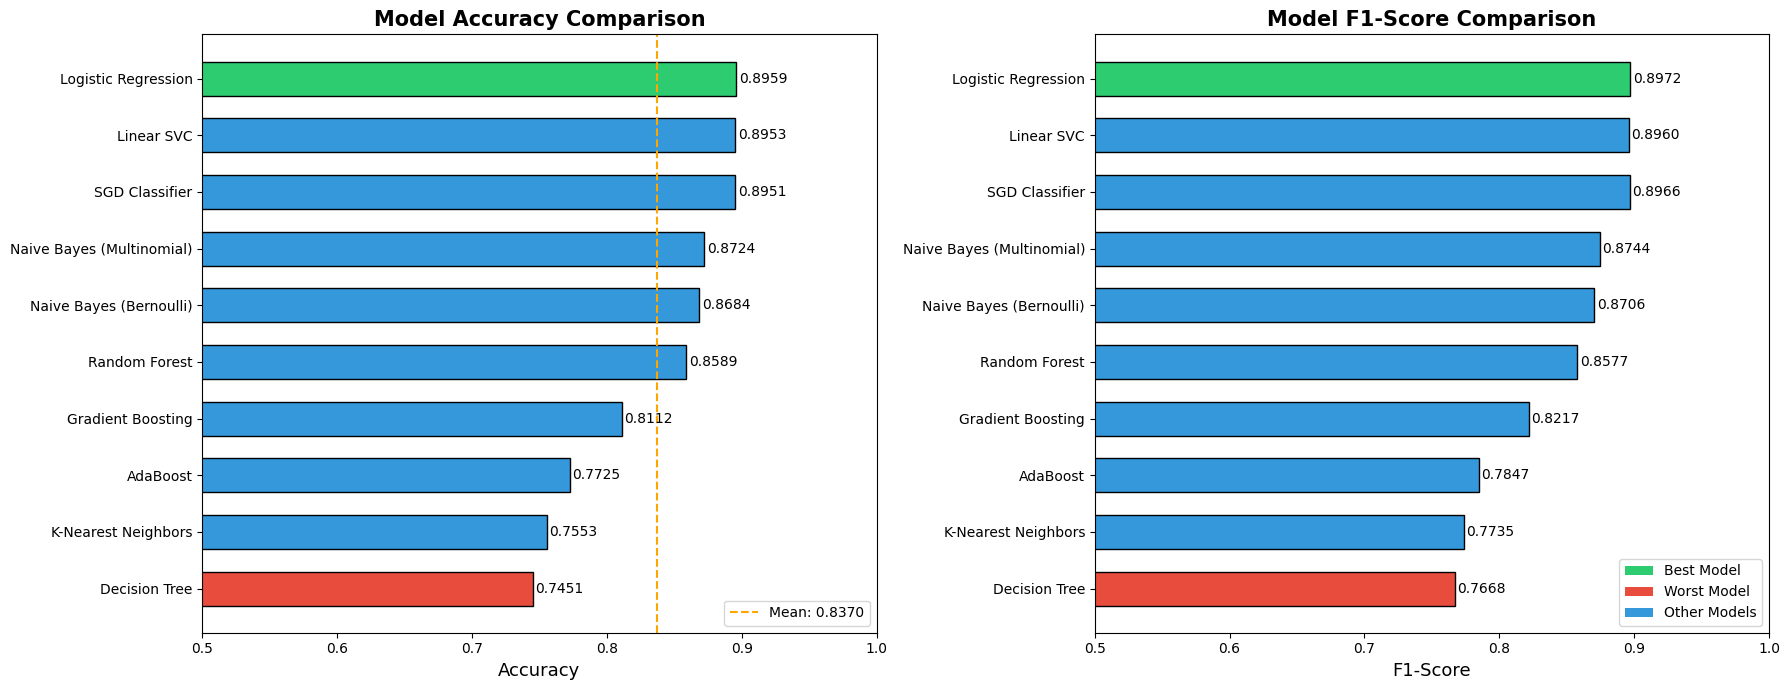

Bar chart saved.


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Sort by accuracy for display
plot_df = results_df.sort_values('Accuracy', ascending=True)
short_names = [m.split('. ')[1] for m in plot_df['Model']]

colors = ['#e74c3c' if i == 0 else ('#2ecc71' if i == len(plot_df)-1 else '#3498db')
          for i in range(len(plot_df))]

# --- Accuracy Bar Chart ---
bars = axes[0].barh(short_names, plot_df['Accuracy'], color=colors, edgecolor='black', height=0.6)
axes[0].set_xlabel('Accuracy', fontsize=13)
axes[0].set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
for bar, val in zip(bars, plot_df['Accuracy']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)
axes[0].axvline(x=plot_df['Accuracy'].mean(), color='orange', linestyle='--', label=f'Mean: {plot_df["Accuracy"].mean():.4f}')
axes[0].legend()

# --- F1 Score Bar Chart ---
bars2 = axes[1].barh(short_names, plot_df['F1-Score'], color=colors, edgecolor='black', height=0.6)
axes[1].set_xlabel('F1-Score', fontsize=13)
axes[1].set_title('Model F1-Score Comparison', fontsize=15, fontweight='bold')
axes[1].set_xlim(0.5, 1.0)
for bar, val in zip(bars2, plot_df['F1-Score']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Best Model'),
                   Patch(facecolor='#e74c3c', label='Worst Model'),
                   Patch(facecolor='#3498db', label='Other Models')]
axes[1].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved.")

All Metrics Comparison

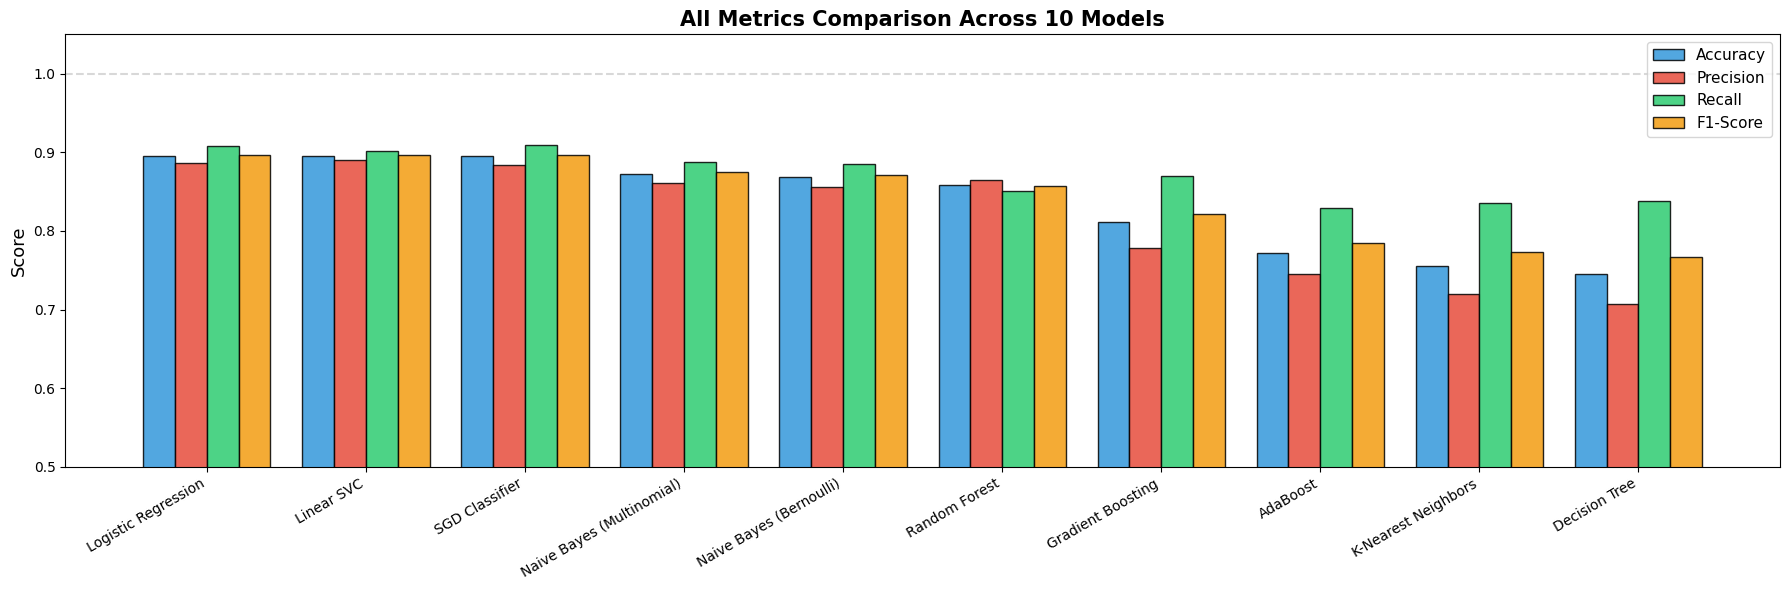

Multi-metric chart saved.


In [43]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2
short_names_sorted = [m.split('. ')[1] for m in results_df['Model']]

fig, ax = plt.subplots(figsize=(18, 6))

colors_metrics = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for i, (metric, color) in enumerate(zip(metrics, colors_metrics)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(short_names_sorted, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('All Metrics Comparison Across 10 Models', fontsize=15, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Multi-metric chart saved.")

Confusion Matrices

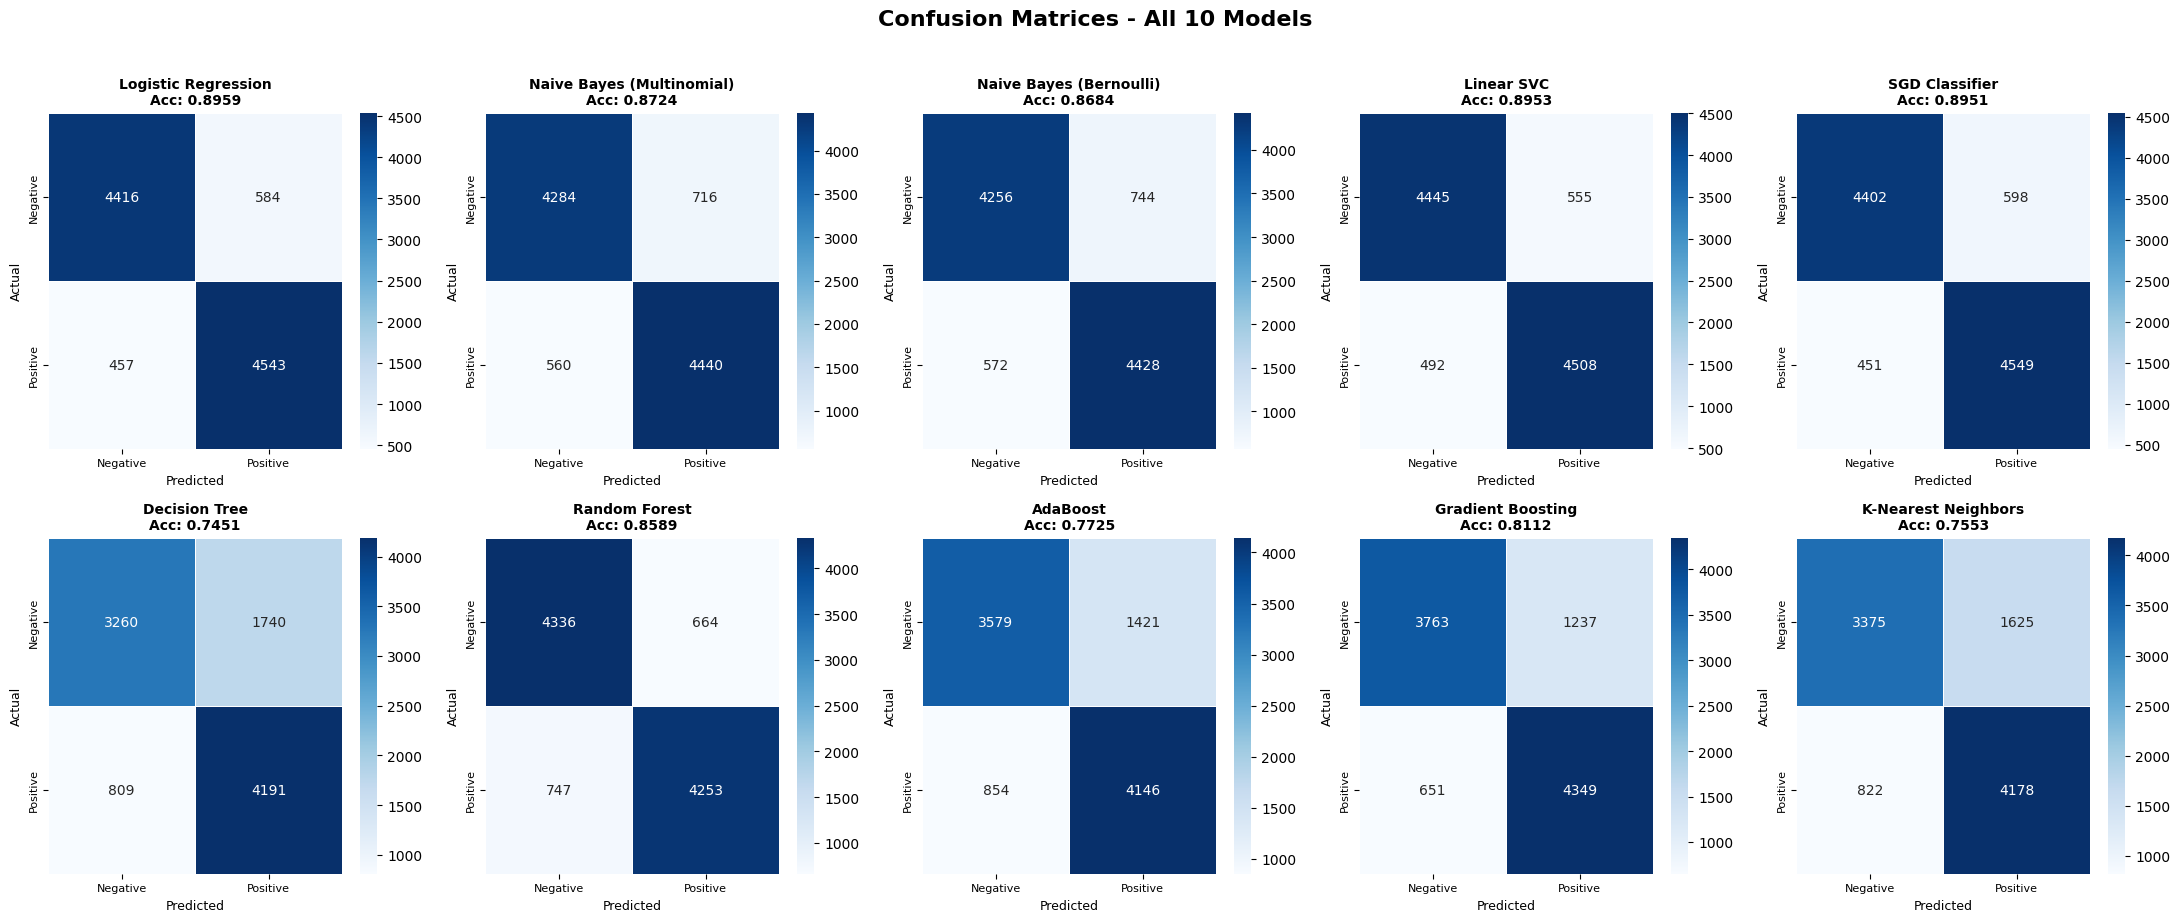

Confusion matrices saved.


In [44]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

labels = ['Negative', 'Positive']

for idx, result in enumerate(results):
    cm = confusion_matrix(y_test, result['y_pred'])
    short_name = result['Model'].split('. ')[1]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=labels, yticklabels=labels, linewidths=0.5)
    axes[idx].set_title(f"{short_name}\nAcc: {result['Accuracy']:.4f}",
                         fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=9)
    axes[idx].set_ylabel('Actual', fontsize=9)
    axes[idx].tick_params(labelsize=8)

plt.suptitle('Confusion Matrices - All 10 Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved.")

Training Time Comparison

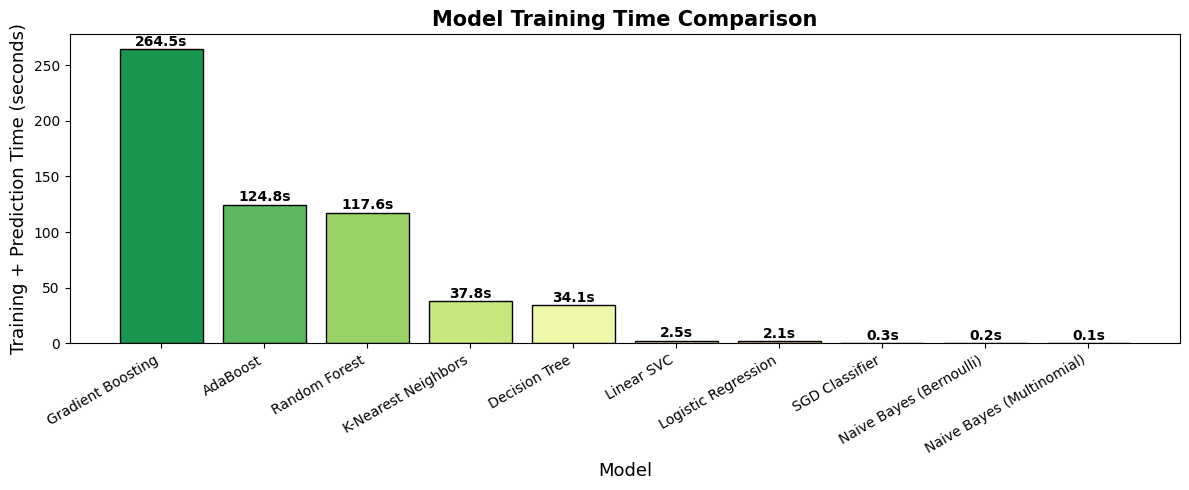

Training time chart saved.


In [45]:
fig, ax = plt.subplots(figsize=(12, 5))

time_df = results_df.sort_values('Time (s)', ascending=False)
short_names_time = [m.split('. ')[1] for m in time_df['Model']]

bar_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(time_df)))
bars = ax.bar(short_names_time, time_df['Time (s)'], color=bar_colors, edgecolor='black')

for bar, val in zip(bars, time_df['Time (s)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Training + Prediction Time (seconds)', fontsize=13)
ax.set_title('Model Training Time Comparison', fontsize=15, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training time chart saved.")

 BoW vs TF-IDF Comparison (Best Model)

Comparing BoW vs TF-IDF using Logistic Regression...

Logistic Regression with BoW   : Accuracy=0.8828 | F1=0.8831
Logistic Regression with TF-IDF: Accuracy=0.8959 | F1=0.8972


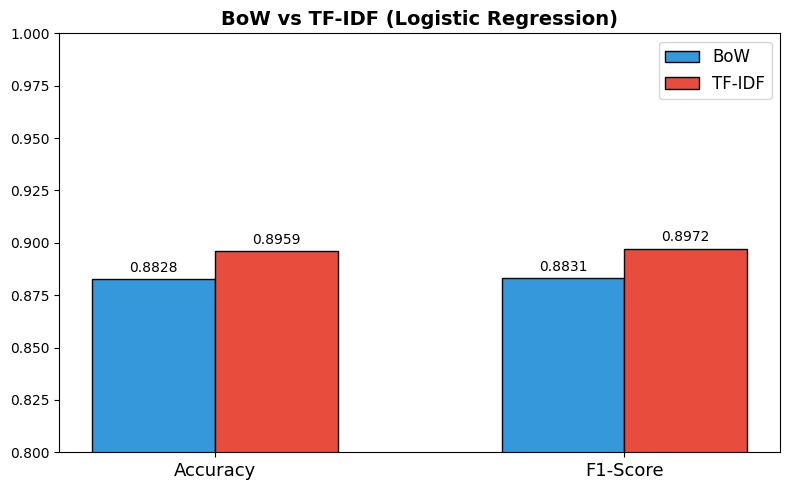

BoW vs TF-IDF chart saved.


In [46]:

print("Comparing BoW vs TF-IDF using Logistic Regression...")

lr = LogisticRegression(max_iter=1000, random_state=42)

# BoW
lr.fit(X_train_bow, y_train)
bow_acc = accuracy_score(y_test, lr.predict(X_test_bow))
bow_f1  = f1_score(y_test, lr.predict(X_test_bow), pos_label='positive')

# TF-IDF
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train_tfidf, y_train)
tfidf_acc = accuracy_score(y_test, lr2.predict(X_test_tfidf))
tfidf_f1  = f1_score(y_test, lr2.predict(X_test_tfidf), pos_label='positive')

print(f"\nLogistic Regression with BoW   : Accuracy={bow_acc:.4f} | F1={bow_f1:.4f}")
print(f"Logistic Regression with TF-IDF: Accuracy={tfidf_acc:.4f} | F1={tfidf_f1:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.3

ax.bar(x - width/2, [bow_acc, bow_f1],   width, label='BoW',   color='#3498db', edgecolor='black')
ax.bar(x + width/2, [tfidf_acc, tfidf_f1], width, label='TF-IDF', color='#e74c3c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1-Score'], fontsize=13)
ax.set_ylim(0.8, 1.0)
ax.set_title('BoW vs TF-IDF (Logistic Regression)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('bow_vs_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
print("BoW vs TF-IDF chart saved.")


Word Embeddings (Word2Vec)

In [47]:
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression

print("Training Word2Vec embeddings...")

# Tokenize for Word2Vec
tokenized_corpus = [text.split() for text in X_train]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5
)

print(f" Word2Vec trained! Vocabulary size: {len(w2v_model.wv)}")

def get_w2v_features(texts, model, vector_size=100):
    """Average Word2Vec embeddings for each document."""
    features = []
    for text in texts:
        tokens = text.split()
        vectors = [model.wv[t] for t in tokens if t in model.wv]
        if vectors:
            features.append(np.mean(vectors, axis=0))
        else:
            features.append(np.zeros(vector_size))
    return np.array(features)

print("Generating Word2Vec feature vectors...")
X_train_w2v = get_w2v_features(X_train, w2v_model)
X_test_w2v  = get_w2v_features(X_test,  w2v_model)

print(f"Feature matrix shape: {X_train_w2v.shape}")

Training Word2Vec embeddings...
 Word2Vec trained! Vocabulary size: 65166
Generating Word2Vec feature vectors...
Feature matrix shape: (40000, 100)


In [48]:
# Train LR on Word2Vec features
print("Training Logistic Regression on Word2Vec features...")
lr_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)

w2v_acc = accuracy_score(y_test, y_pred_w2v)
w2v_f1  = f1_score(y_test, y_pred_w2v, pos_label='positive')

print(f"\n Word2Vec + Logistic Regression:")
print(f"   Accuracy : {w2v_acc:.4f}")
print(f"   F1-Score : {w2v_f1:.4f}")
print(f"\nComparison:")
print(f"   TF-IDF + LR  Accuracy : {tfidf_acc:.4f}")
print(f"   Word2Vec + LR Accuracy: {w2v_acc:.4f}")

Training Logistic Regression on Word2Vec features...

 Word2Vec + Logistic Regression:
   Accuracy : 0.8580
   F1-Score : 0.8585

Comparison:
   TF-IDF + LR  Accuracy : 0.8959
   Word2Vec + LR Accuracy: 0.8580


In [49]:
# Visualize Word2Vec similar words
print("Most similar words to 'excellent':")
print(w2v_model.wv.most_similar('excellent', topn=10))

print("\nMost similar words to 'terrible':")
print(w2v_model.wv.most_similar('terrible', topn=10))

Most similar words to 'excellent':
[('terrific', 0.8668568134307861), ('outstanding', 0.8656028509140015), ('superb', 0.8606510758399963), ('fine', 0.839297354221344), ('fantastic', 0.8391516804695129), ('wonderful', 0.8158672451972961), ('exceptional', 0.7834367156028748), ('brilliant', 0.7734479904174805), ('fabulous', 0.7621661424636841), ('marvelous', 0.7619494795799255)]

Most similar words to 'terrible':
[('horrible', 0.9120921492576599), ('awful', 0.8922578692436218), ('atrocious', 0.7946909666061401), ('dreadful', 0.7881709337234497), ('horrendous', 0.7725086212158203), ('lousy', 0.7712270617485046), ('horrid', 0.752451479434967), ('suck', 0.748289167881012), ('subpar', 0.7267536520957947), ('abysmal', 0.7265222072601318)]



Feature Extraction Method Comparison:
Feature Method  Accuracy  F1-Score
           BoW    0.8828  0.883081
        TF-IDF    0.8959  0.897205
      Word2Vec    0.8580  0.858453


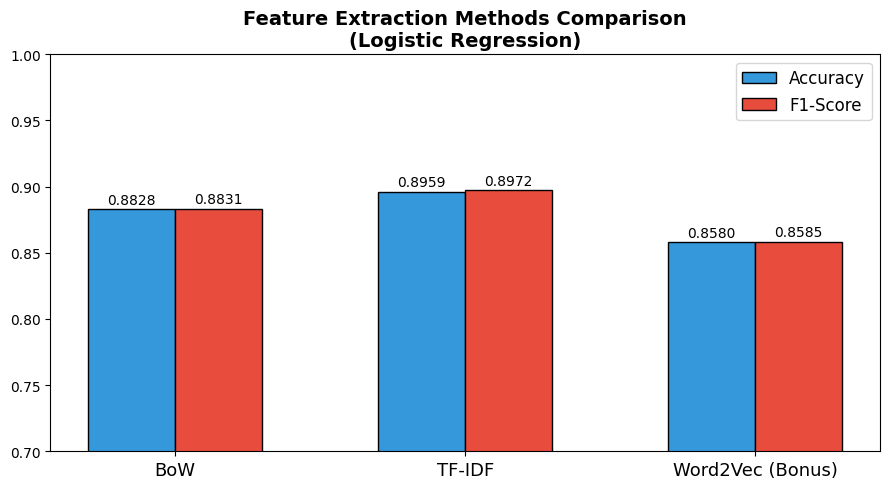

In [50]:
# Final comparison: BoW vs TF-IDF vs Word2Vec
comparison_data = {
    'Feature Method' : ['BoW', 'TF-IDF', 'Word2Vec'],
    'Accuracy'       : [bow_acc, tfidf_acc, w2v_acc],
    'F1-Score'       : [bow_f1,  tfidf_f1,  w2v_f1]
}
comp_df = pd.DataFrame(comparison_data)
print("\nFeature Extraction Method Comparison:")
print(comp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
width = 0.3
ax.bar(x - width/2, comp_df['Accuracy'], width, label='Accuracy', color='#3498db', edgecolor='black')
ax.bar(x + width/2, comp_df['F1-Score'], width, label='F1-Score', color='#e74c3c', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['BoW', 'TF-IDF', 'Word2Vec (Bonus)'], fontsize=13)
ax.set_ylim(0.7, 1.0)
ax.set_title('Feature Extraction Methods Comparison\n(Logistic Regression)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Analysis & Conclusions

In [51]:
print("=" * 70)
print("FINAL ANALYSIS & CONCLUSIONS")
print("=" * 70)

print(f"""
  DATASET:
  - IMDB 50K Movie Reviews (balanced: 50% positive, 50% negative)
  - Train: 40,000 reviews | Test: 10,000 reviews

  PREPROCESSING:
  - Lowercasing, HTML tag removal, punctuation removal
  - Tokenization, stopword removal, lemmatization

  FEATURE EXTRACTION:
  - Bag of Words (BoW): 20,000 features with bigrams
  - TF-IDF: 20,000 features with bigrams
  - Word2Vec (BONUS): 100-dimensional embeddings

  BEST MODEL  : {best_model}
   Accuracy    : {results_df.iloc[0]['Accuracy']:.4f}
   F1-Score    : {results_df.iloc[0]['F1-Score']:.4f}

  WORST MODEL : {worst_model}
   Accuracy    : {results_df.iloc[-1]['Accuracy']:.4f}
   F1-Score    : {results_df.iloc[-1]['F1-Score']:.4f}

  KEY INSIGHTS:
  1. Linear models (LR, SVC, SGD) outperform tree-based models on high-
     dimensional sparse text data.
  2. TF-IDF generally gives slightly better results than BoW because it
     down-weights very common words.
  3. Word2Vec captures semantic meaning but requires larger data and more
     tuning to match TF-IDF + linear models on this task.
  4. KNN is slow on high-dimensional sparse data — dimensionality reduction
     (PCA, SVD) would help.
  5. Decision Tree tends to overfit; Random Forest/Gradient Boosting
     mitigate this via ensemble averaging.
""")

FINAL ANALYSIS & CONCLUSIONS

  DATASET:
  - IMDB 50K Movie Reviews (balanced: 50% positive, 50% negative)
  - Train: 40,000 reviews | Test: 10,000 reviews

  PREPROCESSING:
  - Lowercasing, HTML tag removal, punctuation removal
  - Tokenization, stopword removal, lemmatization

  FEATURE EXTRACTION:
  - Bag of Words (BoW): 20,000 features with bigrams
  - TF-IDF: 20,000 features with bigrams
  - Word2Vec (BONUS): 100-dimensional embeddings

  BEST MODEL  : 1. Logistic Regression
   Accuracy    : 0.8959
   F1-Score    : 0.8972

  WORST MODEL : 6. Decision Tree
   Accuracy    : 0.7451
   F1-Score    : 0.7668

  KEY INSIGHTS:
  1. Linear models (LR, SVC, SGD) outperform tree-based models on high-
     dimensional sparse text data.
  2. TF-IDF generally gives slightly better results than BoW because it
     down-weights very common words.
  3. Word2Vec captures semantic meaning but requires larger data and more
     tuning to match TF-IDF + linear models on this task.
  4. KNN is slow on 